In [2]:
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 100)

In [134]:
#track_record = pd.read_csv('experiments/all_series_final_solution.csv')
#track_record = pd.read_csv('experiments/just_game_id.csv')
track_record = pd.read_csv('artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231202053916/result.csv')
#track_record = pd.read_csv('artefacts/aggregatorGameId_min_games0_do_baselineTrue_20231201230422/result.csv')
track_record.head(20)

,0,1,2,3,4,5
0,2738735,0.480377,5,False,True,2019-04-27
1,2738739,0.000000,5,False,True,2019-04-27
2,2738740,0.185077,5,False,True,2019-04-27
3,2740879,0.125237,4,True,True,2019-04-28
4,2740882,0.075408,5,True,True,2019-04-28
5,2740885,0.034980,5,True,True,2019-04-28
6,2740886,0.755292,5,True,True,2019-04-28
7,2740887,0.045728,5,True,True,2019-04-28
8,2740905,0.046768,5,True,True,2019-04-28
9,2740906,0.058850,5,True,True,2019-04-28


In [136]:
track_record.columns = ['GameId',	'return',	'n_bets', 'time_limit_flag', 'is_valid_solution', 'Datetime']
track_record

,GameId,return,n_bets,time_limit_flag,is_valid_solution,Datetime
0,2738735,0.480377,5,False,True,2019-04-27
1,2738739,0.000000,5,False,True,2019-04-27
2,2738740,0.185077,5,False,True,2019-04-27
3,2740879,0.125237,4,True,True,2019-04-28
4,2740882,0.075408,5,True,True,2019-04-28
...,...,...,...,...,...,...
1327,5924760,0.506040,5,False,True,2022-11-10
1328,5924763,0.313994,5,False,True,2022-11-10
1329,5924764,0.021086,5,False,True,2022-11-10
1330,5924765,0.248516,5,False,True,2022-11-10


In [137]:
print(track_record.shape)
track_record = track_record[track_record.is_valid_solution]
print(track_record[track_record.is_valid_solution].shape)


(1332, 6)
(1239, 6)


In [138]:
track_record.head(20)

,GameId,return,n_bets,time_limit_flag,is_valid_solution,Datetime
0,2738735,0.480377,5,False,True,2019-04-27
1,2738739,0.000000,5,False,True,2019-04-27
2,2738740,0.185077,5,False,True,2019-04-27
3,2740879,0.125237,4,True,True,2019-04-28
4,2740882,0.075408,5,True,True,2019-04-28
5,2740885,0.034980,5,True,True,2019-04-28
6,2740886,0.755292,5,True,True,2019-04-28
7,2740887,0.045728,5,True,True,2019-04-28
8,2740905,0.046768,5,True,True,2019-04-28
9,2740906,0.058850,5,True,True,2019-04-28


In [139]:
def process_results(track_record, aggregator):
    
    count_col = track_record.groupby(aggregator, sort=False).size().reset_index(drop=True)
    #is_valid_solution = track_record.groupby(aggregator, sort=False)['is_valid_solution'].any().reset_index(drop=True)
    track_record = track_record.groupby('Datetime', sort=False)[['return', 'n_bets']].sum().reset_index()
    track_record['count'] = count_col
    #track_record['is_valid_solution'] = is_valid_solution

    return track_record

In [140]:
track_record = process_results(track_record, 'Datetime')
track_record

,Datetime,return,n_bets,count
0,2019-04-27,0.665453,15,3
1,2019-04-28,1.142264,34,7
2,2019-05-02,1.384192,25,5
3,2019-05-04,1.045380,10,2
4,2019-05-05,0.957346,38,8
...,...,...,...,...
284,2022-11-03,1.413580,10,2
285,2022-11-05,1.328331,25,5
286,2022-11-06,1.162436,20,4
287,2022-11-09,1.292047,25,5


In [141]:
# count_col = track_record.groupby(['Datetime']).count().reset_index()['GameId']
# is_valid_solution = track_record.groupby(['Datetime']).any().reset_index()['is_valid_solution']
# track_record = track_record.groupby(['Datetime'])[['return', 'n_bets']].sum().reset_index()
# track_record['count'] = count_col
# track_record['is_valid_solution'] = is_valid_solution
# track_record

In [142]:
print(track_record['return'].corr(track_record['count'], method='kendall'))
print(track_record['return'].corr(track_record['n_bets'],))

-0.06305692177875531
0.0033748791631391254


In [143]:
track_record.groupby(track_record.Datetime.apply(lambda x: x[:4])).count()

,Datetime,return,n_bets,count
Datetime,,,,
2019,64,64,64,64
2020,55,55,55,55
2021,99,99,99,99
2022,71,71,71,71


In [ ]:
track_record.groupby(['count', 'return']).size()

count  return
1      0.000     27
       1.600      1
       1.875      1
       2.480      1
       2.750      1
       3.740      1
       4.200      1
       4.270      1
       5.380      1
       7.190      1
       9.500      1
       11.875     1
       12.160     1
       12.890     1
       13.200     1
       15.740     1
       26.500     1
       28.000     1
dtype: int64

In [144]:
track_record.groupby('count')['return'].median()

count
2    1.078904
3    1.049970
4    1.042634
5    1.032180
6    1.013446
7    1.056106
8    1.026522
Name: return, dtype: float64

In [145]:
print(track_record.shape)
track_record = track_record[track_record.is_valid_solution]
print(track_record.shape)

(289, 4)


AttributeError: 'DataFrame' object has no attribute 'is_valid_solution'

In [146]:
track_record.head()

,Datetime,return,n_bets,count
0,2019-04-27,0.665453,15,3
1,2019-04-28,1.142264,34,7
2,2019-05-02,1.384192,25,5
3,2019-05-04,1.045380,10,2
4,2019-05-05,0.957346,38,8


In [147]:
def compute_stake(df):
    stake = [1]
    current_stake = 1
    percentage = 0.10
    for i in df['return']:

        preserved_stake = current_stake * (1-percentage)
        bet_stake = current_stake*percentage
        current_stake = preserved_stake + bet_stake*i

        #print(current_stake)

        stake.append(current_stake)
    
    return stake

In [149]:
stake = compute_stake(track_record)
stake

[1,
 0.9665453406282603,
 0.9802958030784766,
 1.0179580178368894,
 1.022577534673455,
 1.0182158176071272,
 1.2529256723172986,
 1.2862355489850925,
 1.325913927251298,
 1.3651504977421605,
 1.3698219918637802,
 1.3872524320326576,
 1.464863757317185,
 1.4747632200145295,
 1.5193003946451924,
 1.6889433407160213,
 1.6865861674939573,
 1.6077093944042746,
 1.519473927975002,
 1.529726191637025,
 1.5344564618293937,
 1.6972879944590349,
 1.7019807836406888,
 1.6976059560875383,
 1.6615348497283502,
 1.6333694552744418,
 1.6554400106736564,
 1.6577506781800955,
 1.718783547334574,
 1.8084406941937565,
 1.790494472187859,
 1.791897032078539,
 1.8384336629445308,
 1.9011705750860544,
 1.9020818875418,
 1.9804248027522227,
 1.9776399566451581,
 1.9752342168768944,
 1.9916600801467674,
 2.0680765550892635,
 2.142979271877651,
 2.1486629480249104,
 2.1657268537454475,
 2.09667467886205,
 2.3402196211500486,
 2.2453598285391183,
 2.252265194746954,
 2.4555692548151242,
 2.210012329333612,
 2.2

In [150]:
track_record['Datetime'] = track_record.apply(lambda x: f"{x['Datetime']}_{x['GameId']}", axis=1)

KeyError: 'GameId'

In [151]:
def build_plot_df(df, stake):
    return pd.DataFrame({'date': ['0'] + list(df.Datetime),
                        'return': [0] + list(df['return']),
                        #'count': [0] + list(df['count']),
                        #'n_bets': [0] + list(df.n_bets),
                        'stake':stake})
my_df = build_plot_df(track_record, stake)
my_df

,date,return,stake
0,0,0.000000,1.000000
1,2019-04-27,0.665453,0.966545
2,2019-04-28,1.142264,0.980296
3,2019-05-02,1.384192,1.017958
4,2019-05-04,1.045380,1.022578
...,...,...,...
285,2022-11-03,1.413580,7.558542
286,2022-11-05,1.328331,7.806712
287,2022-11-06,1.162436,7.933521
288,2022-11-09,1.292047,8.165217


In [152]:
my_df[my_df.stake == my_df.stake.max()]

,date,return,stake
289,2022-11-10,1.336482,8.439963


In [153]:
def plot_strategy(df):
    # Create a line plot
    plt.figure(figsize=(20, 6))
    plt.plot(df.date, df.stake, linestyle='-')
    plt.title('Cumulative Profits Over Time (%)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profits')
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [157]:
df_strategy = my_df.copy().iloc[1:]
df_strategy.date = pd.to_datetime(df_strategy.date)

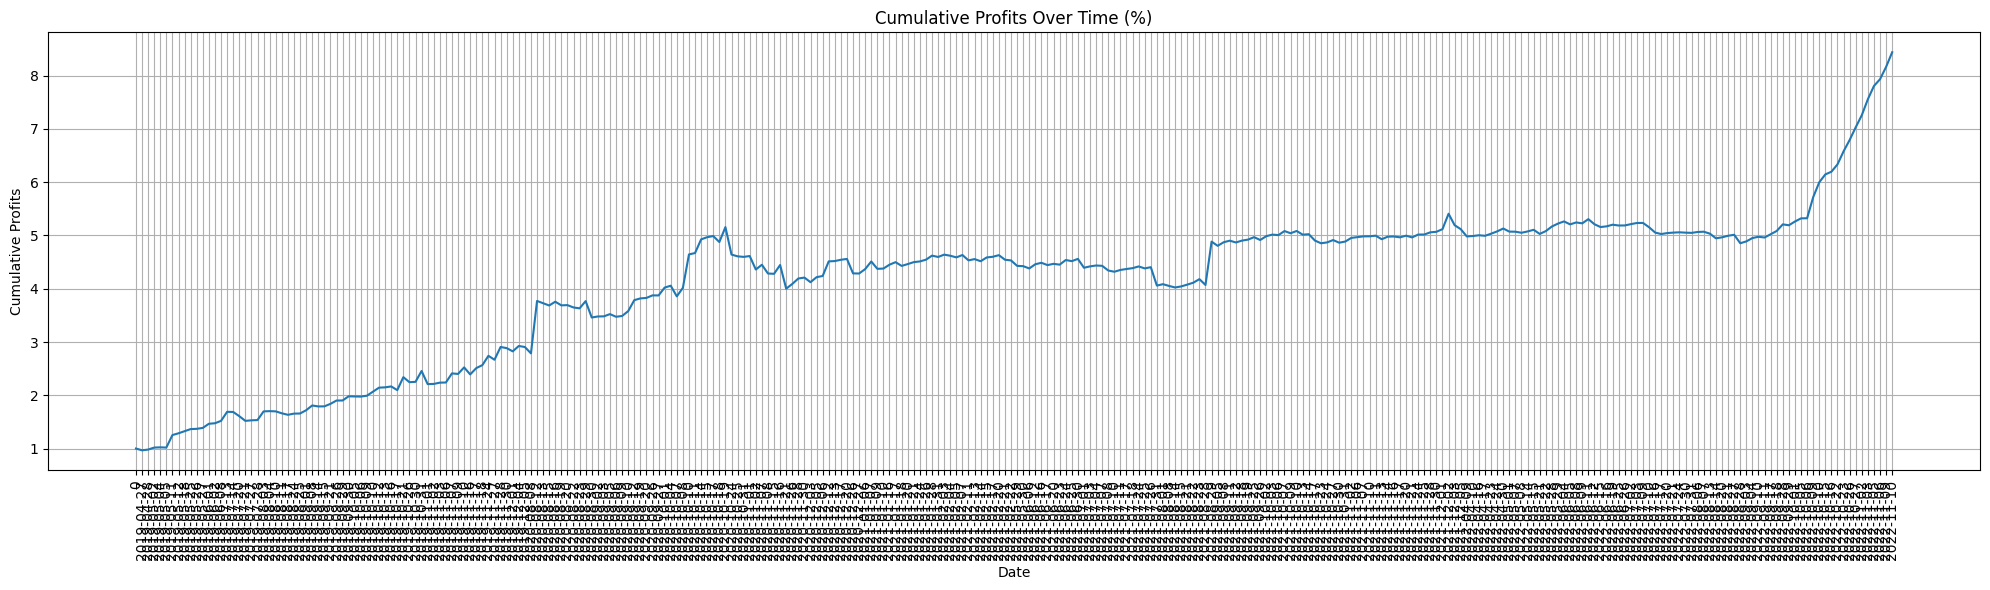

In [159]:
plot_strategy(my_df)
#plot_strategy(df_strategy)

In [19]:
track_record.loc[:, 'year'] = track_record['datetime'].apply(lambda x: x[:4])
track_record

C:\Users\Marcos Augusto\AppData\Local\Temp\ipykernel_14456\3960167630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  track_record.loc[:, 'year'] = track_record['datetime'].apply(lambda x: x[:4])


,datetime,return,n_bets,count,is_valid_solution,year
0,2019-04-27,0.665453,15,3,True,2019
1,2019-04-28,1.148989,34,7,True,2019
3,2019-05-02,1.383096,25,5,True,2019
4,2019-05-04,1.045380,10,2,True,2019
5,2019-05-05,0.966362,38,8,True,2019
...,...,...,...,...,...,...
308,2022-11-03,1.413580,10,2,True,2022
309,2022-11-05,1.332791,25,5,True,2022
310,2022-11-06,1.161109,20,4,True,2022
311,2022-11-09,1.286985,25,5,True,2022


## Break by year

Year: 2019


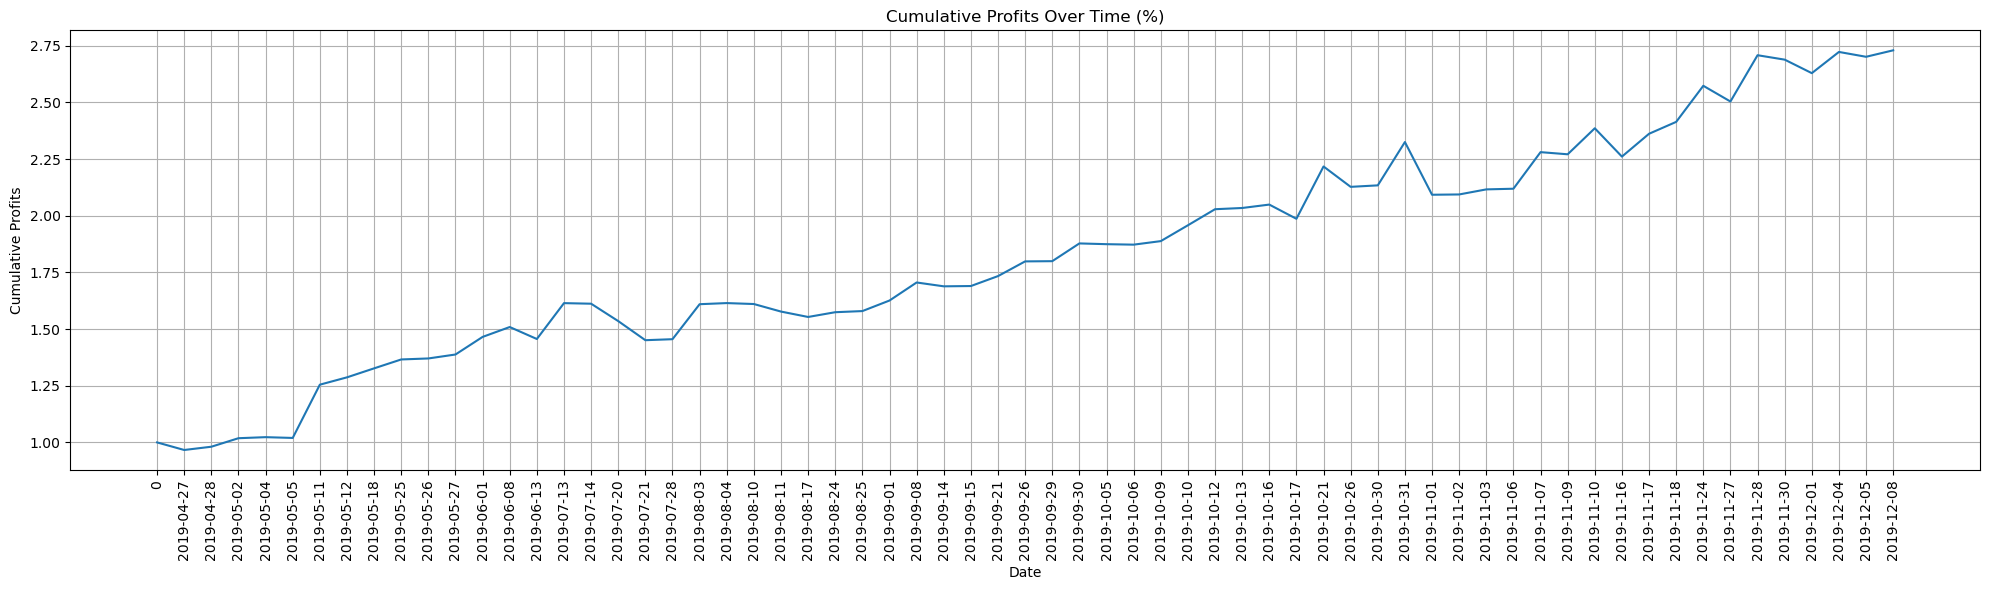

Year: 2020


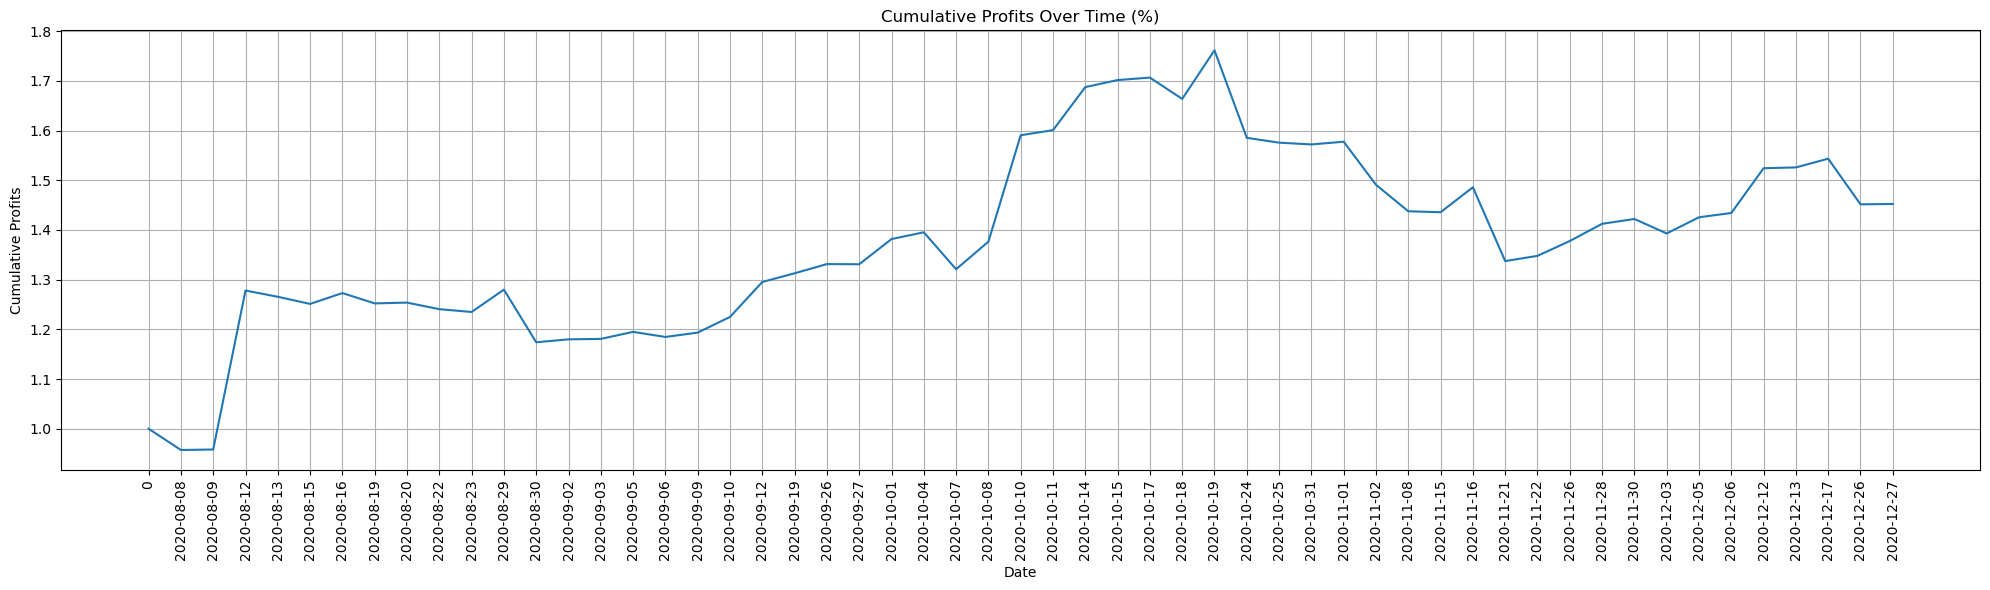

Year: 2021


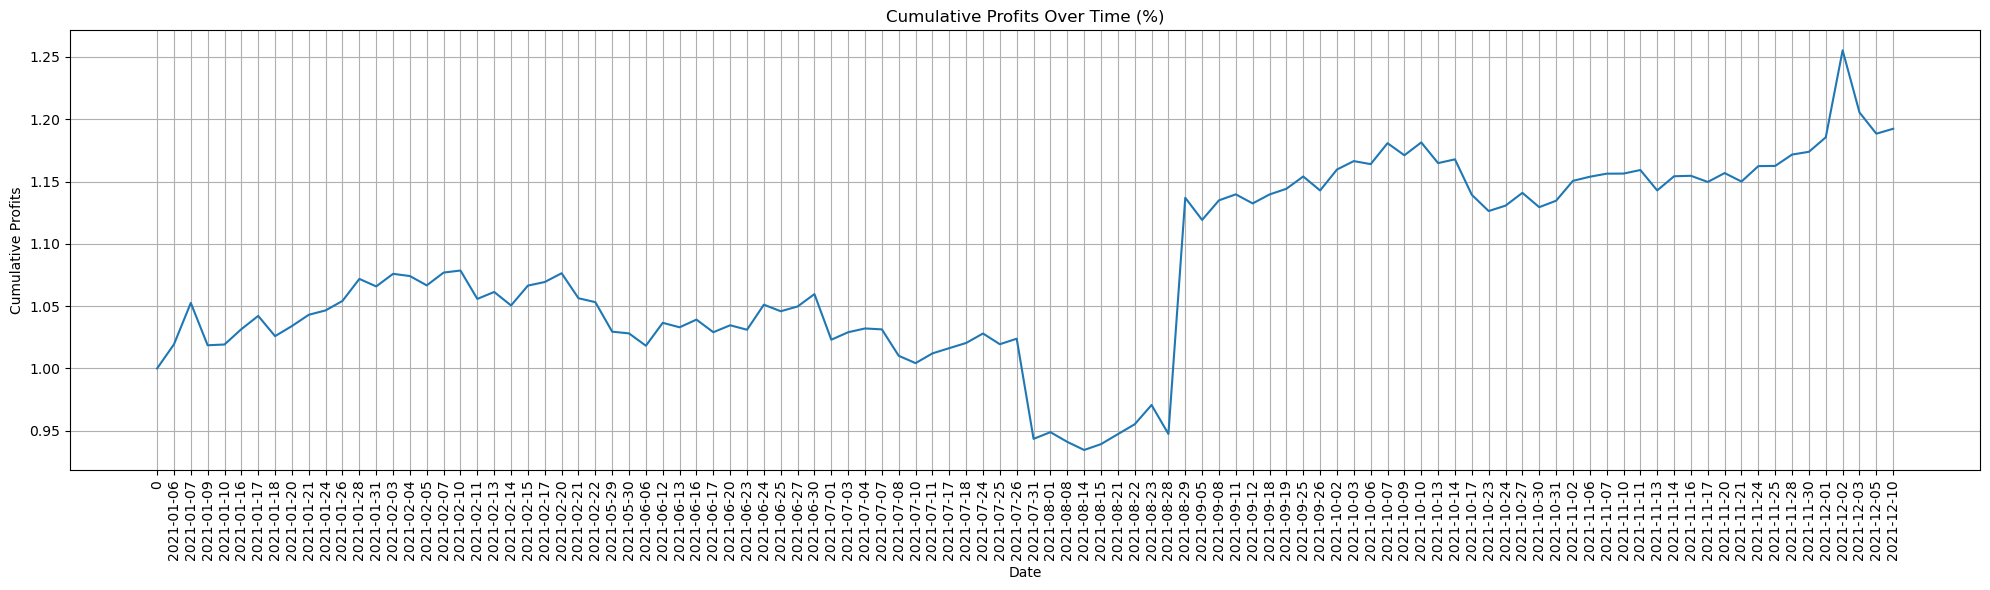

Year: 2022


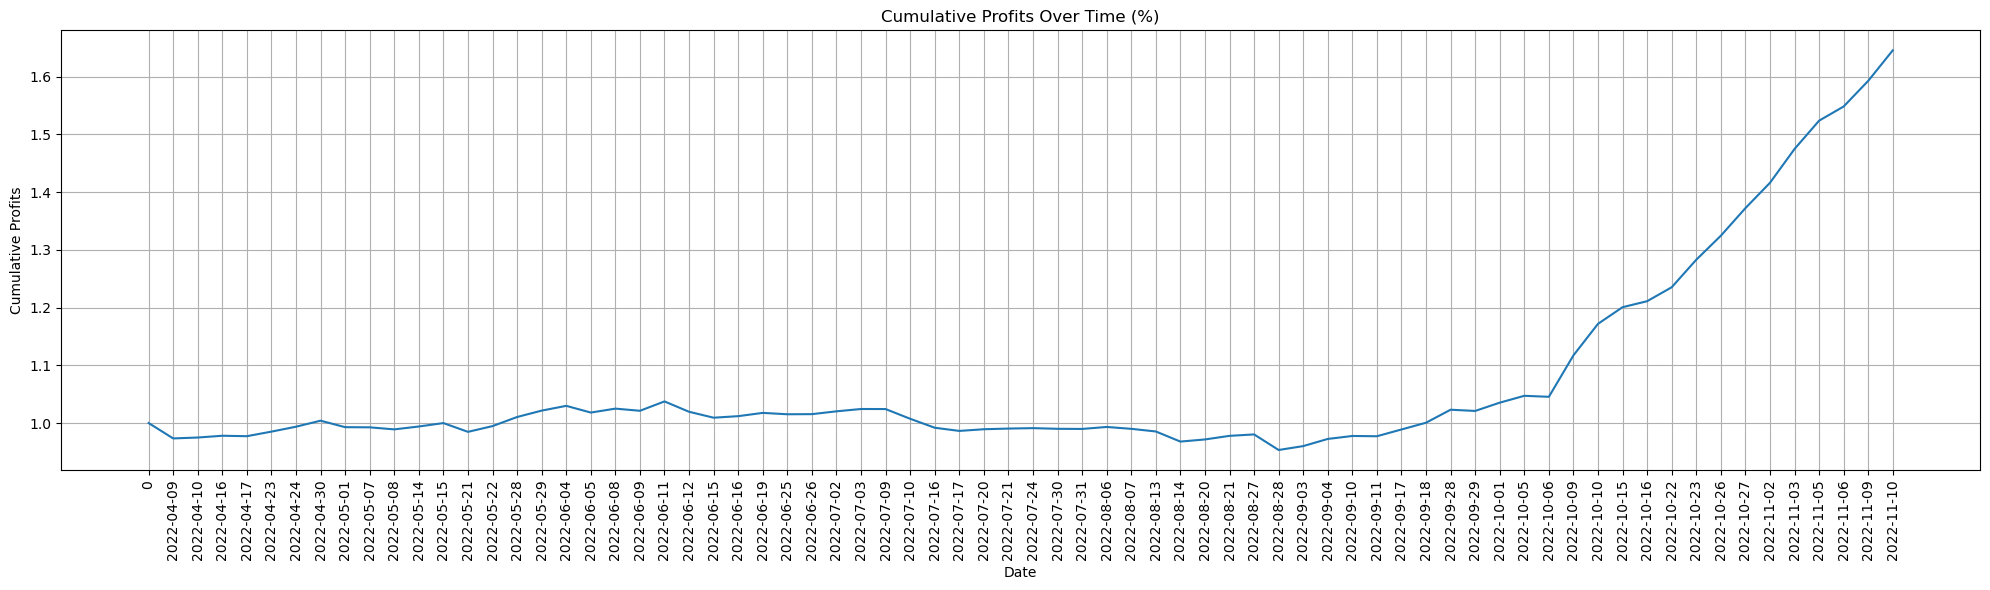

In [20]:
for year in track_record.year.unique():
    print(f"Year: {year}")
    df = track_record[track_record['year']==year]
    stake = compute_stake(df)
    my_df = build_plot_df(df, stake)
    plot_strategy(df)

## Baseline + strategy

In [3]:
df_strategy = pd.read_csv("artefacts/botorch_aggregatorDatetime_min_games1_bookmakers8_do_baselineFalse_20240405083038/result_plot.csv").iloc[1:]
df_baseline1 = pd.read_csv("artefacts/aggregatorDatetime_min_games1_bookmakers8_do_baselineFalse_20240405085613/result_plot.csv").iloc[1:]
df_baseline1['date'] = df_baseline1.date.apply(lambda x: x[:10])
print(df_baseline1.shape)
df_baseline1 = df_baseline1.groupby('date', sort=False).last().reset_index().iloc[1:]
print(df_baseline1.shape)
df_baseline2 = pd.read_csv("artefacts/mobo_aggregatorDatetime_min_games1_bookmakers8_do_baselineFalse_20240405100436/result_plot.csv")
df_baseline2['date'] = df_baseline2.date.apply(lambda x: x[:10])
df_baseline2 = df_baseline2.groupby('date', sort=False).last().reset_index().iloc[1:]


#df_strategy = pd.read_csv("artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231201163246/result_plot.csv")
df_strategy

(307, 3)
(306, 3)


,date,return,stake
1,2019-04-27,0.989568,0.998957
2,2019-04-28,3.572194,1.255908
3,2019-05-01,0.704485,1.218794
4,2019-05-02,1.667401,1.300136
5,2019-05-04,0.986728,1.298411
...,...,...,...
306,2022-11-03,1.424036,24.122502
307,2022-11-05,1.352109,24.971877
308,2022-11-06,1.115747,25.260918
309,2022-11-09,1.237969,25.862050


In [18]:
# df_strategy = pd.read_csv("artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231201163246/result_plot.csv").iloc[1:]
# df_strategy = pd.read_csv("artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231202053916/result_plot.csv").iloc[1:]
# df_baseline1 = pd.read_csv("artefacts/aggregatorGameId_min_games0_do_baselineTrue_20231201231551/result_plot.csv")
# df_baseline1['date'] = df_baseline1.date.apply(lambda x: x[:10])
# df_baseline1 = df_baseline1.groupby('date', sort=False).last().reset_index().iloc[1:]

# df_baseline2 = pd.read_csv("artefacts/aggregatorGameId_min_games0_do_baselineTrue_20231202014701/result_plot.csv")
# df_baseline2['date'] = df_baseline2.date.apply(lambda x: x[:10])
# df_baseline2 = df_baseline2.groupby('date', sort=False).last().reset_index().iloc[1:]


# #df_strategy = pd.read_csv("artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231201163246/result_plot.csv")
# df_baseline2

In [19]:
#df_strategy.date = pd.to_datetime(df_strategy.date)
#df_baseline1.date = pd.to_datetime(df_baseline1.date)
#df_baseline2.date = pd.to_datetime(df_baseline2.date)

In [10]:
import argparse
import datetime
import math
import os
from time import time
from typing import Any, List, Tuple

import numpy as np
import pandas as pd
import torch
from joblib import Parallel, delayed

from artifacts import (
build_plot_df_wrapper,
save_csv_artifact,
save_plot_strategy,
)
from BoTorchOptimizer import BoTorchOptimizer
from data import (
apply_final_treatment,
join_metadata,
load_metadata_artefacts,
load_odds,
)
from dependencies.config import load_config
from dependencies.utils import get_bet_return, softmax
from filter import filter_by_linear_combination
from GameProbs import GameProbs


config = load_config("config/config.yml")


def setup(args):
    metadata, gameid_to_outcome = load_metadata_artefacts(config.metadata_path)
    odds = load_odds(config.odds_path, args.bookmakers)
    print(odds.shape)
    odds = join_metadata(odds, metadata)

    odds = odds.sort_values(["Datetime", "GameId"], ascending=True)

    #odds = odds[(odds.Datetime.apply(str)>"2021-05-26")]
    odds = odds[(odds.Datetime.apply(str)>"2019-05-01") & (odds.Datetime.apply(str)<"2019-05-05")]
    return odds, gameid_to_outcome

In [12]:
#if __name__ == "__main__":
parser = argparse.ArgumentParser()
parser.add_argument(
    "--aggregator",
    type=str,
    help="aggregate by GameId or by Datetime"
)
parser.add_argument(
    "--min_games",
    type=int,
    default=0,
    help="threshold of minimum number of games to enter the optimization task"
)
parser.add_argument(
    "--bookmakers",
    type=int,
    default=None,
    help="threshold of minimum number of games to enter the optimization task"
)
parser.add_argument(
    "--do_baseline",
    action='store_true',
    help="flag to apply baseline logic or not, not specifying the argument return the opposite of the action"
)
parser.add_argument(
    "--save_experiment",
    action='store_true',
    help="flag to save the experiment artefacts, not specifying the argument return the opposite of the action"
)
#args = parser.parse_args()
args = parser.parse_args([
"--aggregator", "Datetime",
"--min_games", "1",
#"--do_baseline", "False"
#"--save_experiment"
])
print(args)
#run_strategy(args)

odds, gameid_to_outcome = setup(args)

Namespace(aggregator='Datetime', min_games=1, bookmakers=None, do_baseline=False, save_experiment=False)
(2003933, 7)


In [20]:
odds.GameId.values[0]

'2744172'

In [13]:
odds

,GameId,Sportsbook,Market,Scenario,Bet,Odd,public_prob,Home,Away,Datetime
13756,2744172,Bet365,h2h,,home,3.60,0.277778,Fortaleza,Athletico-PR,2019-05-02
13757,2744172,Bet365,h2h,,draw,3.00,0.333333,Fortaleza,Athletico-PR,2019-05-02
13758,2744172,Bet365,h2h,,away,2.20,0.454545,Fortaleza,Athletico-PR,2019-05-02
13759,2744172,Bet365,over/under,0.5,over,1.10,0.909091,Fortaleza,Athletico-PR,2019-05-02
13760,2744172,Bet365,over/under,0.5,under,7.50,0.133333,Fortaleza,Athletico-PR,2019-05-02
...,...,...,...,...,...,...,...,...,...,...
20464,2746106,NordicBet,exact,5 : 0,o,250.00,0.004000,Vasco da Gama,Corinthians,2019-05-04
20465,2746106,NordicBet,exact,5 : 1,o,225.00,0.004444,Vasco da Gama,Corinthians,2019-05-04
20466,2746106,NordicBet,exact,6 : 0,o,250.00,0.004000,Vasco da Gama,Corinthians,2019-05-04
20467,2746106,NordicBet,both_score,,yes,2.04,0.490196,Vasco da Gama,Corinthians,2019-05-04


In [4]:
#df = pd.read_csv("artefacts/botorch_aggregatorDatetime_min_games1_bookmakers10_do_baselineFalse_20240419103808/result_plot.csv")
#df = pd.read_csv("artefacts/botorch_aggregatorDatetime_min_games1_bookmakers20_do_baselineFalse_20240419122130/result_plot.csv")
#df = pd.read_csv("artefacts/botorch_aggregatorDatetime_min_games1_bookmakersNone_do_baselineFalse_20240427013200/result_plot.csv")
df = pd.read_csv("artefacts/20240725014807/result_plot.csv")

df

,date,return,stake,n_favorable_bets
0,0,0.000000,1.000000,0
1,2023-04-15,0.000000,0.900000,88
2,2023-04-16,0.000000,0.810000,68
3,2023-04-22,0.000000,0.729000,84
4,2023-04-23,0.000000,0.656100,82
5,2023-04-29,3.912570,0.847194,74
6,2023-04-30,0.000000,0.762474,75
7,2023-05-07,7.540614,1.261179,87
8,2023-05-10,0.000000,1.135061,89
9,2023-05-11,0.000000,1.021555,78


<Figure size 2400x2400 with 0 Axes>

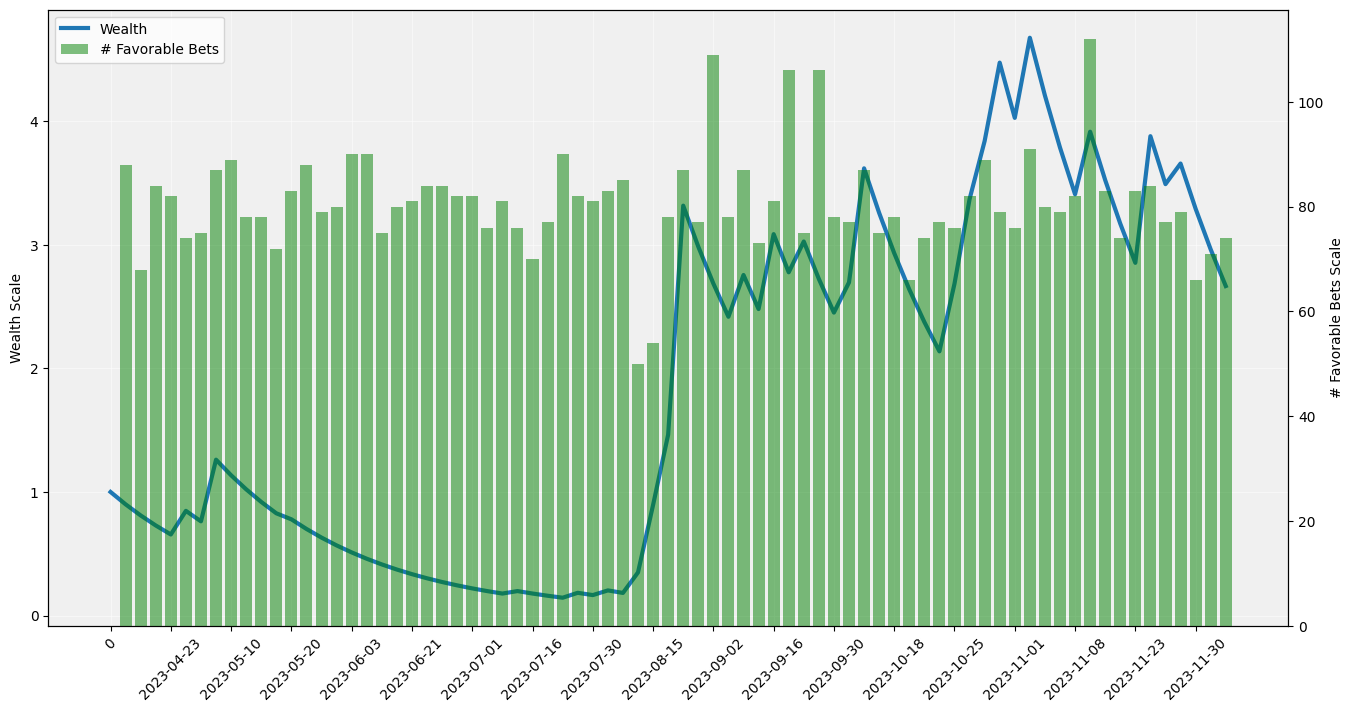

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'df' is your DataFrame and 'date' contains date strings
# Example DataFrame creation if not provided
# df = pd.DataFrame({
#     'date': ['2021-01-01', '2021-01-02', '2021-01-03', ...],
#     'stake': [10, 15, 20, ...],
#     'n_favorable_bets': [2, 3, 5, ...]
# })

plt.figure(figsize=(24, 24))

# Create a figure and a primary axis
fig, ax1 = plt.subplots(figsize=(16, 8))

# Set the axes background color
ax1.set_facecolor('#f0f0f0')

# First line plot on the primary y-axis
line1, = ax1.plot(df.date, df.stake, label='Wealth', linewidth=3)
ax1.set_ylabel('Wealth Scale')
ax1.tick_params(axis='y')

# Manually setting x-ticks
# Assuming you want to set ticks at every nth point for clarity, with n determined by your data size
n = max(1, len(df) // 16)  # Adjust n as necessary based on your data size
selected_ticks = df['date'][::n]  # Select every nth date for ticks
ax1.set_xticks(selected_ticks)
ax1.set_xticklabels(selected_ticks, rotation=45)  # Rotate labels to prevent overlap

# Setting a simple white grid aligned with the primary y-axis
ax1.grid(True, color='white', linestyle='-', linewidth=0.5, alpha=0.7)  # White grid lines

# Create a secondary y-axis for the second line plot
ax2 = ax1.twinx()
bars = ax2.bar(df.date, df.n_favorable_bets, color='g', label='# Favorable Bets', width=.8, alpha=0.5)  # White bars with some transparency
ax2.set_ylabel('# Favorable Bets Scale')
ax2.tick_params(axis='y')

# Add legends and title
#plt.title('Dual Y-Axis Line Plots with String Dates')
lines = [line1, bars]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper left')

# Show the plot
plt.show()


<Figure size 2400x2400 with 0 Axes>

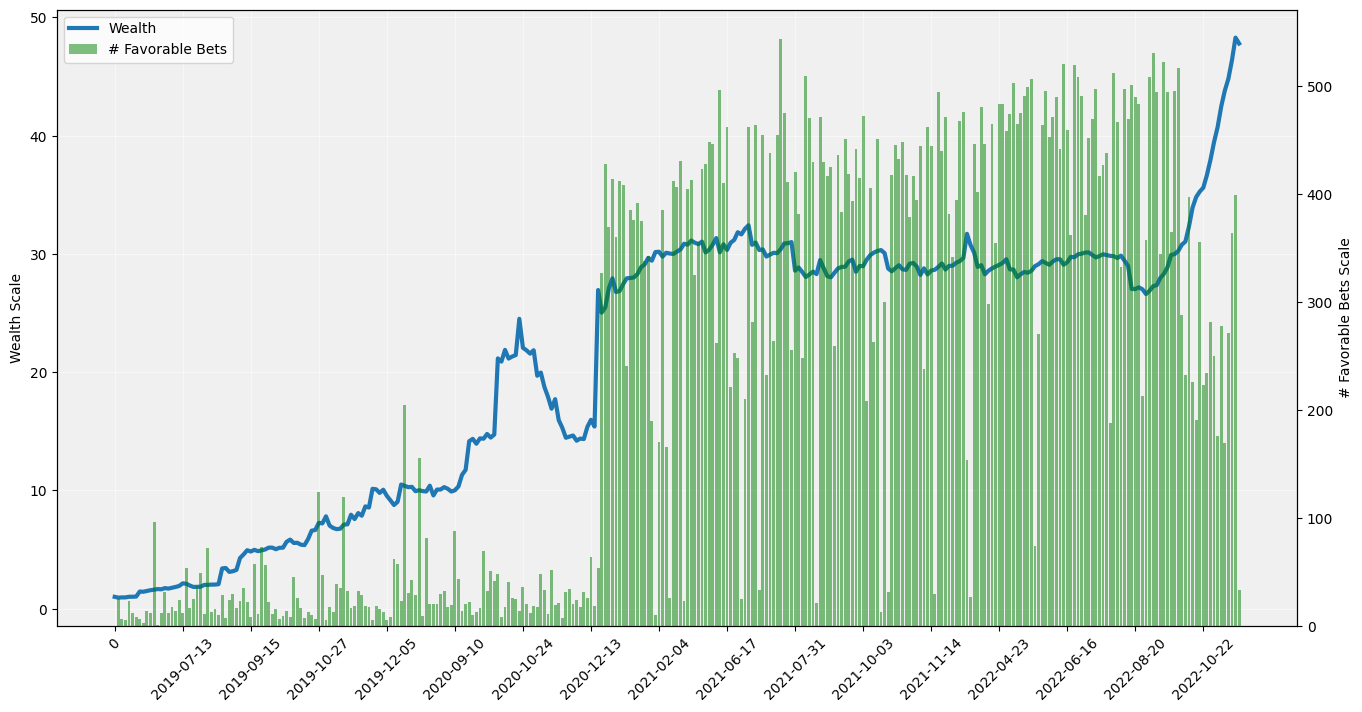

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming 'df' is your DataFrame and 'date' contains date strings
# Example DataFrame creation if not provided
# df = pd.DataFrame({
#     'date': ['2021-01-01', '2021-01-02', '2021-01-03', ...],
#     'stake': [10, 15, 20, ...],
#     'n_favorable_bets': [2, 3, 5, ...]
# })

plt.figure(figsize=(24, 24))

# Create a figure and a primary axis
fig, ax1 = plt.subplots(figsize=(16, 8))

# Set the axes background color
ax1.set_facecolor('#f0f0f0')

# First line plot on the primary y-axis
line1, = ax1.plot(df.date, df.stake, label='Wealth', linewidth=3)
ax1.set_ylabel('Wealth Scale')
ax1.tick_params(axis='y')

# Manually setting x-ticks
# Assuming you want to set ticks at every nth point for clarity, with n determined by your data size
n = max(1, len(df) // 16)  # Adjust n as necessary based on your data size
selected_ticks = df['date'][::n]  # Select every nth date for ticks
ax1.set_xticks(selected_ticks)
ax1.set_xticklabels(selected_ticks, rotation=45)  # Rotate labels to prevent overlap

# Setting a simple white grid aligned with the primary y-axis
ax1.grid(True, color='white', linestyle='-', linewidth=0.5, alpha=0.7)  # White grid lines

# Create a secondary y-axis for the second line plot
ax2 = ax1.twinx()
bars = ax2.bar(df.date, df.n_favorable_bets, color='g', label='# Favorable Bets', width=.8, alpha=0.5)  # White bars with some transparency
ax2.set_ylabel('# Favorable Bets Scale')
ax2.tick_params(axis='y')

# Add legends and title
#plt.title('Dual Y-Axis Line Plots with String Dates')
lines = [line1, bars]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper left')

# Show the plot
plt.show()


In [6]:
import pandas as pd
df = pd.DataFrame({
    'date': ['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04', '2021-01-05'],
    'stake': [10, 15, 20, 25, 30],
    'n_favorable_bets': [2, 3, 5, 7, 9]
})
df.head(20)

,date,stake,n_favorable_bets
0,2021-01-01,10,2
1,2021-01-02,15,3
2,2021-01-03,20,5
3,2021-01-04,25,7
4,2021-01-05,30,9


<Figure size 2400x2400 with 0 Axes>

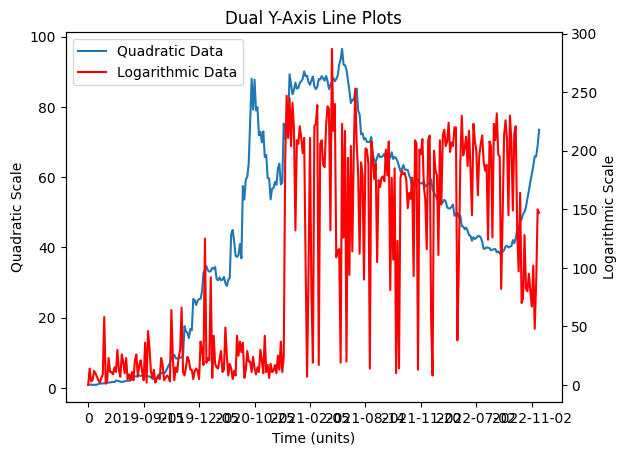

In [49]:
plt.figure(figsize=(24, 24))

# Create a figure and a primary axis
fig, ax1 = plt.subplots()

# First line plot on the primary y-axis
line1, = ax1.plot(df.date, df.stake, label='Quadratic Data')
ax1.set_xlabel('Time (units)')
ax1.set_ylabel('Quadratic Scale')
ax1.tick_params(axis='y')

# Manually setting x-ticks
selected_ticks = df['date'][::len(df) // 8]  # Adjust the step size as needed
#plt.xticks(selected_ticks, rotation=90)
ax1.set_xticks(selected_ticks)


# Create a secondary y-axis for the second line plot
ax2 = ax1.twinx()
line2, = ax2.plot(df.date, df.n_favorable_bets, color='r', label='Logarithmic Data')
ax2.set_ylabel('Logarithmic Scale')
ax2.tick_params(axis='y')


# Add legends and title
plt.title('Dual Y-Axis Line Plots')
lines = [line1, line2]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper left')

# Show the plot
plt.show()

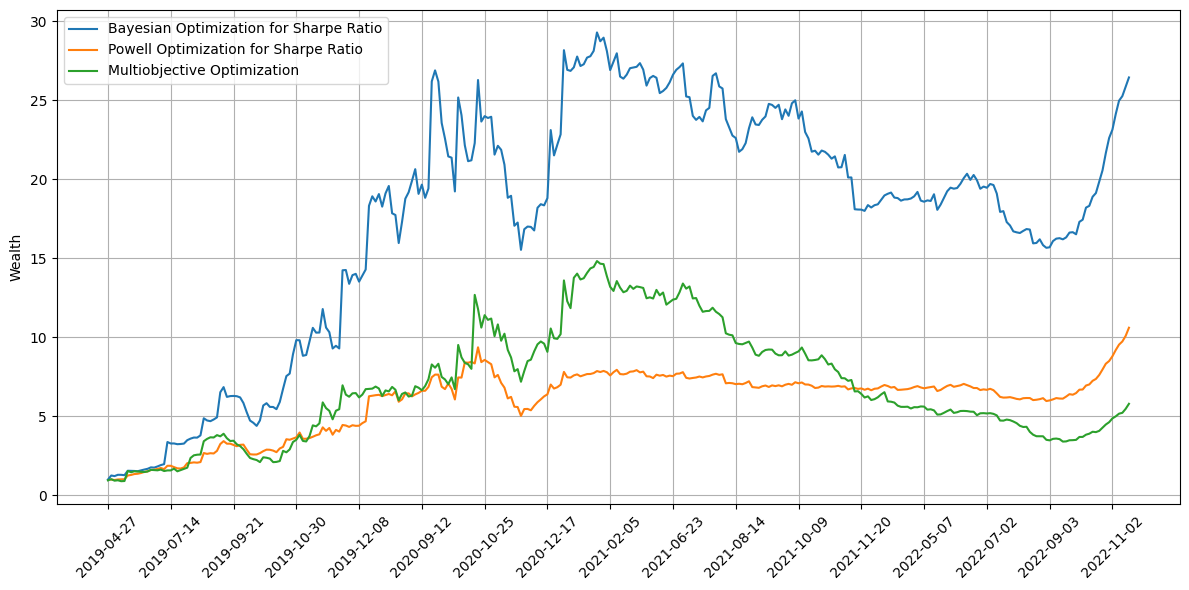

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df_strategy.date, df_strategy.stake, label='Bayesian Optimization for Sharpe Ratio')
plt.plot(df_baseline1.date, df_baseline1.stake, label='Powell Optimization for Sharpe Ratio')
plt.plot(df_baseline2.date, df_baseline2.stake, label='Multiobjective Optimization')
# Manually setting x-ticks
selected_ticks = df_strategy['date'][::len(df_strategy) // 16]  # Adjust the step size as needed
plt.xticks(selected_ticks, rotation=45)
#plt.xlabel('Date')
plt.ylabel('Wealth')
#plt.xticks(rotation=90)
#plt.title('Cumulative Profits Over Time (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [163]:
import os
current_directory = os.getcwd()

# List all files in the current directory
os.listdir(f"{current_directory}/artefacts")

['aggregatorDatetime_min_games1_do_baselineFalse_20231201163246',
 'aggregatorDatetime_min_games1_do_baselineFalse_20231202024415',
 'aggregatorDatetime_min_games1_do_baselineFalse_20231202053916',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202215726',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202220322',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202220626',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202220918',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202221330',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202221543',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202222007',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202222248',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202223049',
 'aggregatorGameId_min_games0_do_baselineTrue_20231202223238']

aggregatorGameId_min_games0_do_baselineTrue_20231202215726
aggregatorGameId_min_games0_do_baselineTrue_20231202220322
aggregatorGameId_min_games0_do_baselineTrue_20231202220626
aggregatorGameId_min_games0_do_baselineTrue_20231202220918
aggregatorGameId_min_games0_do_baselineTrue_20231202221330
aggregatorGameId_min_games0_do_baselineTrue_20231202221543
aggregatorGameId_min_games0_do_baselineTrue_20231202222007
aggregatorGameId_min_games0_do_baselineTrue_20231202222248
aggregatorGameId_min_games0_do_baselineTrue_20231202223049
aggregatorGameId_min_games0_do_baselineTrue_20231202223238


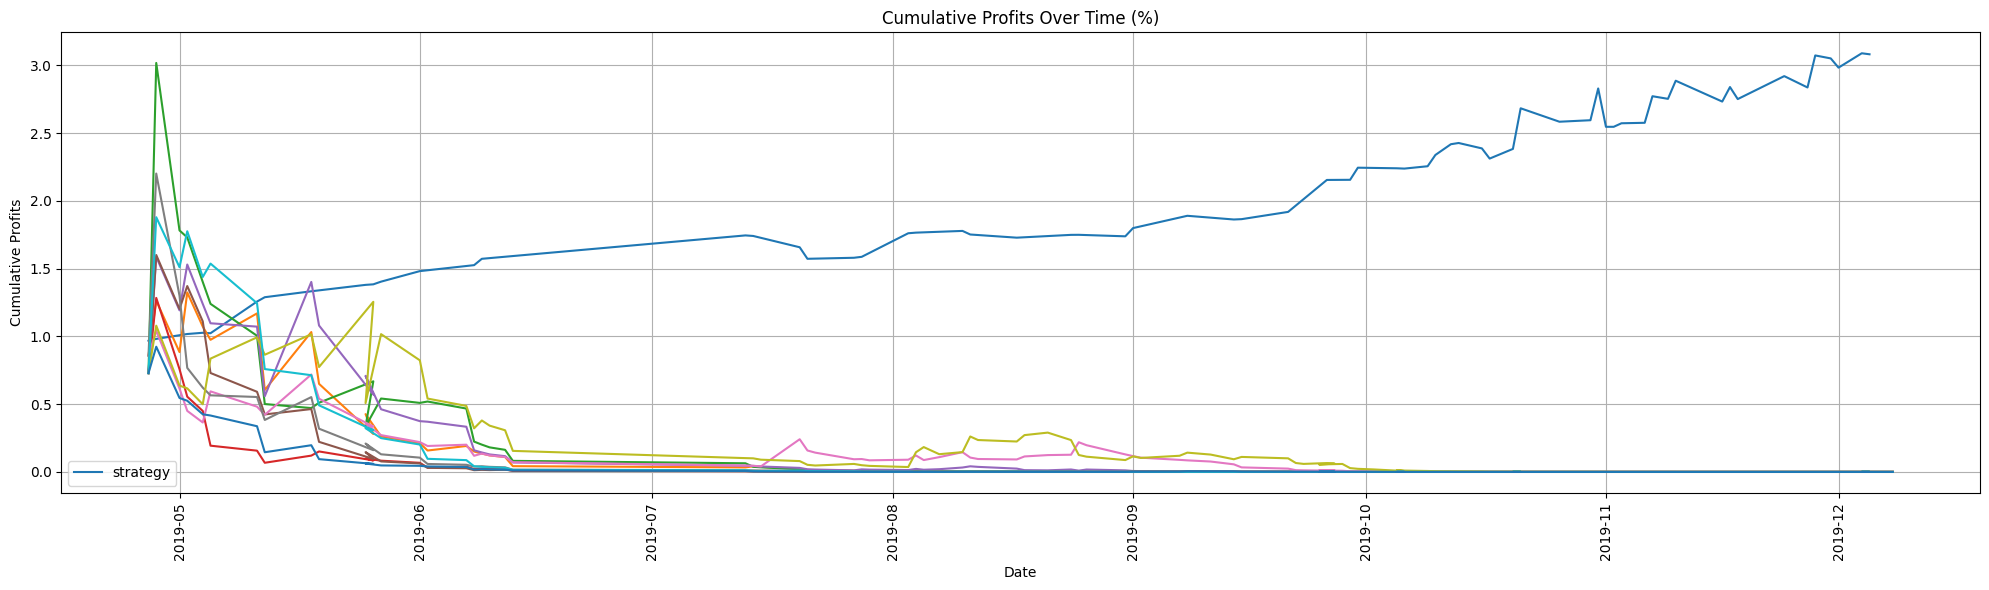

In [175]:
df_strategy = pd.read_csv("artefacts/aggregatorDatetime_min_games1_do_baselineFalse_20231201163246/result_plot.csv").iloc[1:]
df_strategy.date = pd.to_datetime(df_strategy.date)

plt.figure(figsize=(20, 6))
plt.plot(df_strategy.date, df_strategy.stake, label='strategy')

current_directory = os.getcwd()
artefacts_path = f"{current_directory}\\artefacts"
for file in os.listdir(artefacts_path):
    if 'baselineTrue' in file:
        df_baseline = pd.read_csv(f"{artefacts_path}\\{file}\\result_plot.csv")
        df_baseline['date'] = df_baseline.date.apply(lambda x: x[:10])
        df_baseline = df_baseline.groupby('date', sort=False).last().reset_index().iloc[1:]
        df_baseline.date = pd.to_datetime(df_baseline.date)
        plt.plot(df_baseline.date, df_baseline.stake)

        print(file)

plt.xlabel('Date')
plt.ylabel('Cumulative Profits')
plt.xticks(rotation=90)
plt.title('Cumulative Profits Over Time (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

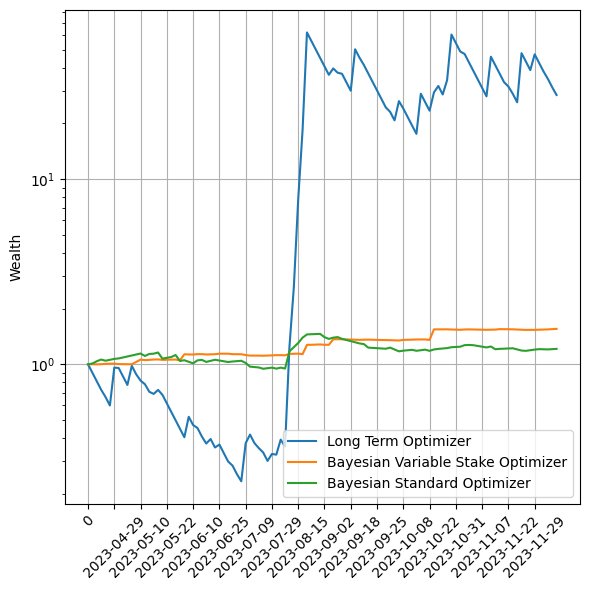

In [15]:
df = pd.read_csv("artefacts/20240823080121/result_plot.csv") # serious-rat-570 
df_variable_stake = pd.read_csv("artefacts/20240823094357/result_plot.csv") # bustling-bat-273 
df_botorch = pd.read_csv("artefacts/20240823091550/result_plot.csv") # rogue-cub-654 
plt.figure(figsize=(6, 6))
plt.plot(df.date, df.stake, label='Long Term Optimizer')
plt.plot(df_variable_stake.date, df_variable_stake.stake, label='Bayesian Variable Stake Optimizer')
plt.plot(df_botorch.date, df_botorch.stake, label='Bayesian Standard Optimizer')

# Manually setting x-ticks
selected_ticks = df['date'][::len(df) // 16]  # Adjust the step size as needed
plt.xticks(selected_ticks, rotation=45)
#plt.xlabel('Date')
plt.ylabel('Wealth')
#plt.xticks(rotation=90)
#plt.title('Cumulative Profits Over Time (%)')

plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()